In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
sys.path.append("/extdata4/baeklab/Hyeonseo/m6A/modformer")
from utils.utils import printmessage
import glob
import tqdm
import pickle


In [35]:
plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [2]:
ON0092_df_path = "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0092/ON0092/result/dorado-070/intermediates/segmented_tokenized/signal_analysis/sampled.pkl"
ON0093_df_path = "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0093/ON0093/result/dorado-070/intermediates/segmented_tokenized/signal_analysis/sampled.pkl"
ON0096_df_path = "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0096/result/dorado-070/intermediates/segmented_tokenized/signal_analysis/sampled.pkl"
ON0098_df_path = "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0098/result/dorado-070/intermediates/segmented_tokenized/signal_analysis/sampled.pkl"
ON0099_df_path = "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0099/result/dorado-070/intermediates/segmented_tokenized/signal_analysis/sampled.pkl"


In [3]:
df_dict = {"ON0092": ON0092_df_path, "ON0093": ON0093_df_path, "ON0096": ON0096_df_path, "ON0098": ON0098_df_path, "ON0099": ON0099_df_path}
df_dict = {k: pd.read_pickle(v) for k, v in df_dict.items()}

In [23]:
ON0118_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/ON0118/ON0118/result/intermediates/block_df.pkl")

In [24]:
ON0118_df = ON0118_df[ON0118_df["penalty"]==0]
ON0118_df["5mer"] = ON0118_df["motif"].apply(lambda x: x[8:13])
print(ON0118_df)

           cb_idx  start_pos  end_pos  pos_RM  penalty  score  \
0               1          9       30      19        0    1.0   
1               2         36       57      46        0    1.0   
7               2        291      312     301        0    1.0   
9               1        353      374     363        0    1.0   
10              2        380      401     390        0    1.0   
...           ...        ...      ...     ...      ...    ...   
161167071       2          7       28      17        0    1.0   
161167074       2          8       29      18        0    1.0   
161167078       2         10       31      20        0    1.0   
161167088       2          9       30      19        0    1.0   
161167095       2          7       28      17        0    1.0   

                                        read_id  total_score  \
0          0bf21221-429f-44ab-b27b-74859f45e4c5    30.357143   
1          0bf21221-429f-44ab-b27b-74859f45e4c5    30.357143   
7          0bf21221-429f-44

In [25]:
ON0118_df = ON0118_df.groupby(["5mer", "cb_idx"])

In [26]:
sampled_list = []
sample_size = 800
for name, group in tqdm.tqdm(ON0118_df):
    sampled_list.append(group.sample(sample_size))
sampled_df = pd.concat(sampled_list)

print(sampled_df)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 768/768 [11:48<00:00,  1.08it/s]


           cb_idx  start_pos  end_pos  pos_RM  penalty  score  \
61212579        0         76       97      86        0    1.0   
154985639       0        134      155     144        0    1.0   
138986397       0         67       88      77        0    1.0   
79183427        0        475      496     485        0    1.0   
83305625        0        223      244     233        0    1.0   
...           ...        ...      ...     ...      ...    ...   
102182582       2        400      421     410        0    1.0   
41751531        2        141      162     151        0    1.0   
106214433       2        238      259     248        0    1.0   
130355897       2        135      156     145        0    1.0   
115723788       2        382      403     392        0    1.0   

                                        read_id  total_score  \
61212579   727fc7ba-4986-4a21-b829-3dfd5809511c    16.071429   
154985639  f84f19fb-3467-43b3-a48f-7a02b0788a08     8.619048   
138986397  ebef9912-858a-4a

In [27]:
import gc
del sampled_list
del ON0118_df
gc.collect()

509

In [28]:
sampled_df.to_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/ON0118/ON0118/result/intermediates/sampled_df.pkl")

In [29]:
df_dict["ON0118"] = sampled_df

In [30]:

def bq_plot(block_df_dict, color_dict, sample=int(1e+4), output="bq_plot.png"):
    ## Plot the distribution of base quality. Plot position-wise mean with CI95.

    stat_dict = {}
    for block_name, block_df in block_df_dict.items():
        if sample is not None:
            block_df = block_df.sample(sample)
        bq_arr = np.stack(block_df["bq"].values, axis=0)
        bq_mean = np.mean(bq_arr, axis=0)
        bq_std = np.std(bq_arr, axis=0)
        bq_ci95 = 1.96*bq_std/np.sqrt(len(bq_arr))
        stat_dict[block_name] = (bq_mean, bq_ci95)

    plt.rcParams.update({'font.size': 24})
    fig, ax = plt.subplots(figsize=(20,10))
    for block_name, block_df in block_df_dict.items():
        pos_bq_mean, pos_bq_ci95 = stat_dict[block_name]
        ax.plot(pos_bq_mean, color=color_dict[block_name], label=f"{block_name} (n={len(block_df):,})")
        ax.fill_between(np.arange(len(pos_bq_mean)), pos_bq_mean-pos_bq_ci95, pos_bq_mean+pos_bq_ci95,
                        color=color_dict[block_name], alpha=0.3)
    ax.set_title("Base Quality Distribution")
    ax.set_xlabel("Position")
    ax.set_ylabel("Mean Base Quality")
    ax.legend()
    plt.savefig(f"{output}", dpi=300)
    plt.show()
    return None


In [36]:
warm_color_list = ["tomato", "coral", "orange", "gold", "goldenrod", "chocolate"]
cool_color_list = ["royalblue", "dodgerblue", "deepskyblue", "skyblue", "lightblue", "powderblue"]

color_dict = {"ON0092": cool_color_list[0], "ON0096": cool_color_list[1], 
              "ON0093": warm_color_list[0], "ON0098": warm_color_list[1], "ON0099": warm_color_list[2], "ON0118": warm_color_list[3]}

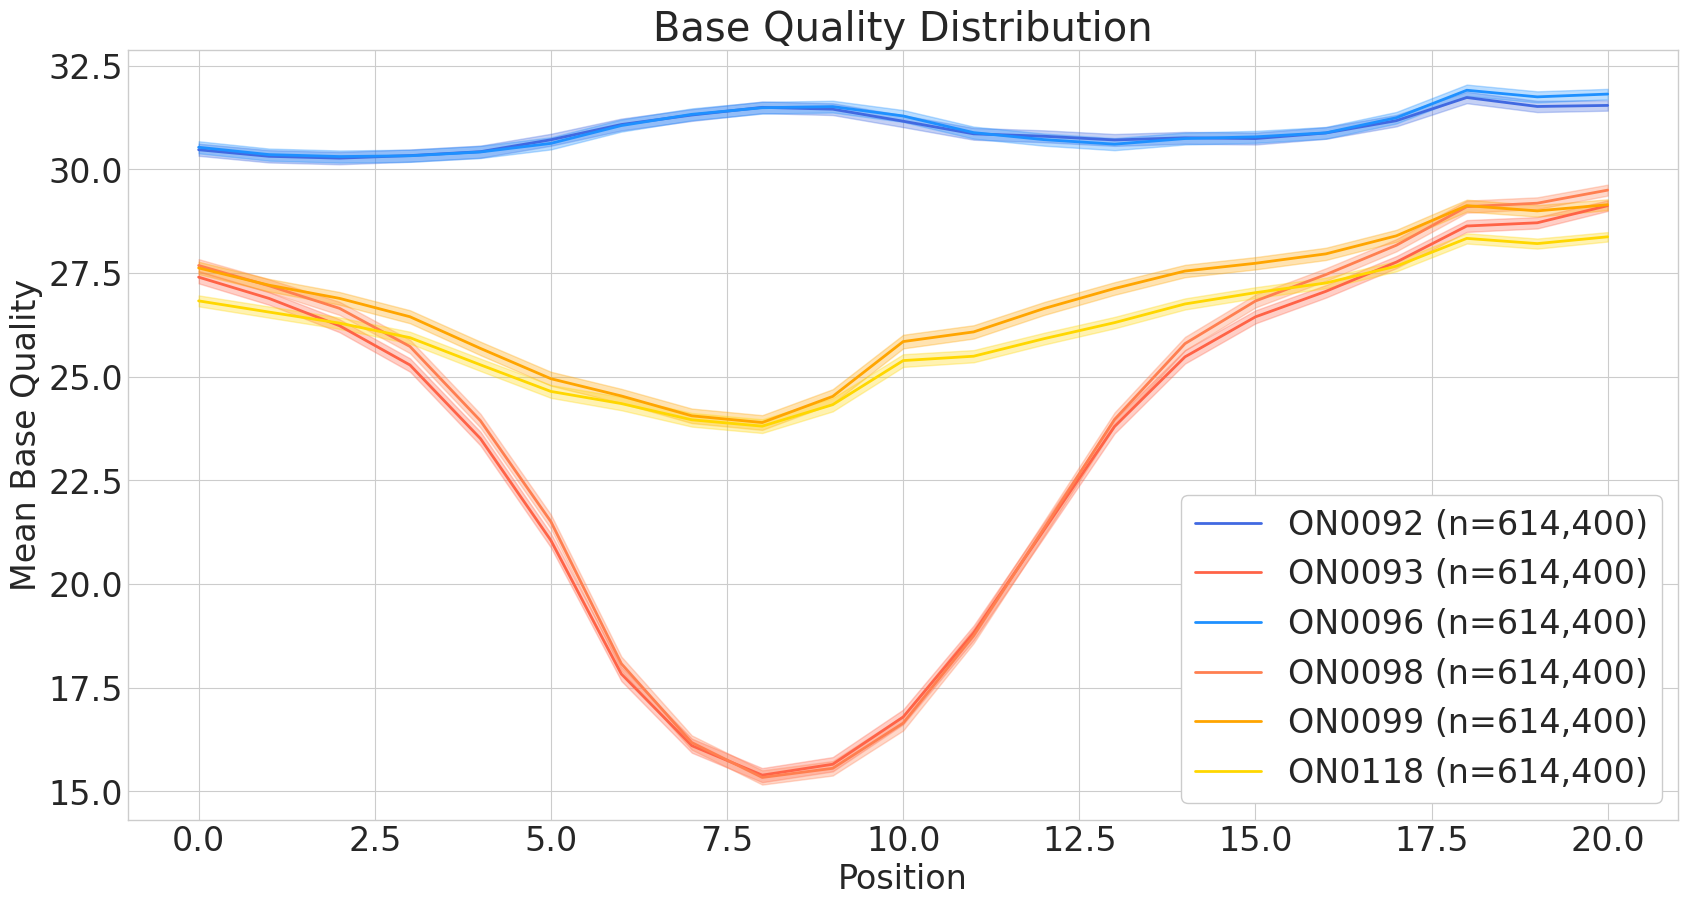

In [37]:
bq_plot(df_dict, color_dict, output="/extdata4/baeklab/Hyeonseo/m6A/plot/qc_251124/bq_plot_balanced.png")

In [38]:

def plot_violin(block_df_dict, color_dict, output):
    cb_len = 21
    ## merge df
    df_list = []
    color_list = []
    for name, df in block_df_dict.items():
        df = df[["bq"]].copy()
        df = df.sample(frac=0.1)
        bq_idx = range(cb_len)
        df["bq_idx"] = np.tile(bq_idx, (len(df),1)).tolist()
        df = df.explode(["bq", "bq_idx"])
        df["name"] = name
        df["bq"] = df["bq"].astype(int)
        df["bq_idx"] = df["bq_idx"].astype(int)
        df = df.dropna()
        df_list.append(df)
        print(df)
        color_list.append(color_dict[name])

    palette = sns.color_palette(color_list)

    df = pd.concat(df_list).reset_index(drop=True)
    print(df)

    fig, ax = plt.subplots(1, 1, figsize=(40,20))
    sns.violinplot(x="bq_idx", y="bq", hue="name", data=df, ax=ax, palette=palette, linewidth=0.5,
                   inner=None, hue_order=list(block_df_dict.keys()))
    ax.set_title("Base Quality Distribution")
    ax.set_xlabel("Position")
    ax.set_ylabel("Base Quality")
    ax.legend(loc = 'lower right', fontsize=20)
    plt.savefig(f"{output}", dpi=300)

    return None


        bq  bq_idx    name
176753  33       0  ON0092
176753  34       1  ON0092
176753  34       2  ON0092
176753  33       3  ON0092
176753  34       4  ON0092
...     ..     ...     ...
124272  28      16  ON0092
124272  27      17  ON0092
124272  28      18  ON0092
124272  28      19  ON0092
124272  30      20  ON0092

[1290240 rows x 3 columns]
        bq  bq_idx    name
44236   32       0  ON0093
44236   31       1  ON0093
44236   30       2  ON0093
44236   31       3  ON0093
44236   31       4  ON0093
...     ..     ...     ...
511566  16      16  ON0093
511566  26      17  ON0093
511566  26      18  ON0093
511566  30      19  ON0093
511566  30      20  ON0093

[1290240 rows x 3 columns]
        bq  bq_idx    name
135191  31       0  ON0096
135191  30       1  ON0096
135191  30       2  ON0096
135191  31       3  ON0096
135191  30       4  ON0096
...     ..     ...     ...
249082  30      16  ON0096
249082  30      17  ON0096
249082  31      18  ON0096
249082  31      19  ON0096

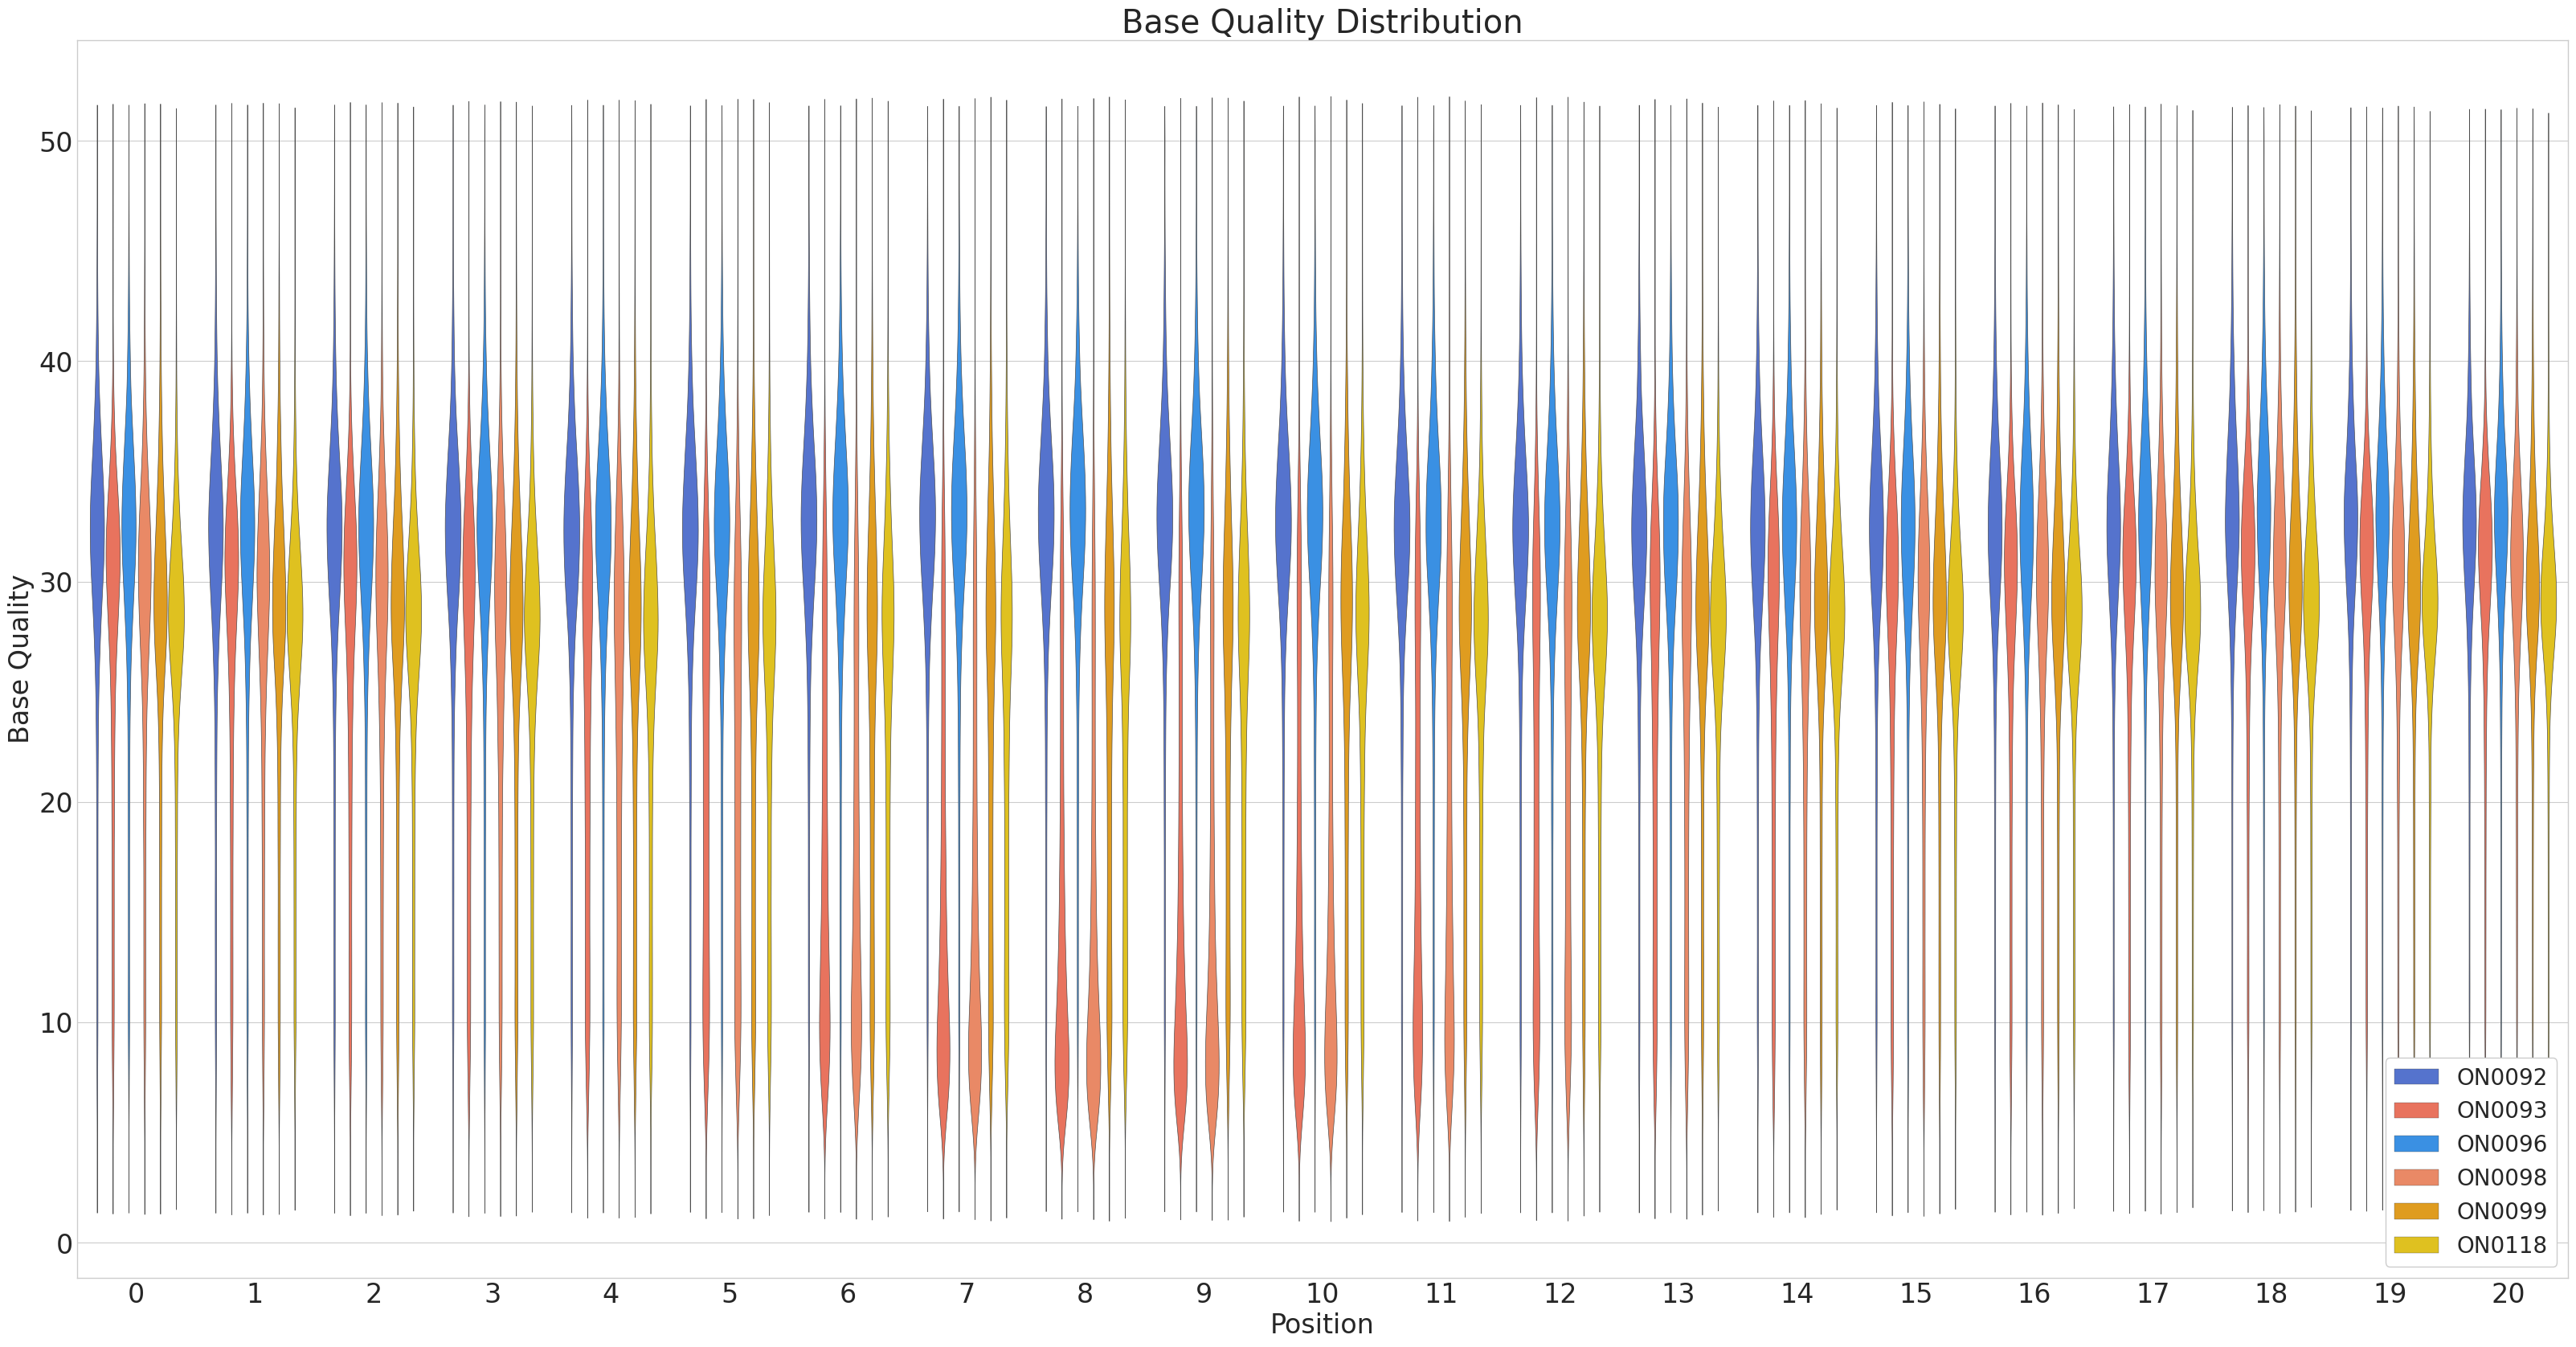

In [39]:
plot_violin(df_dict, color_dict, output="/extdata4/baeklab/Hyeonseo/m6A/plot/qc_251124/bq_violin_balanced.png")

In [ ]:
score_ON0092 = np.load("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0092/ON0092/result/dorado-070/intermediates/score.npy")
score_ON0093 = np.load("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0093/ON0093/result/dorado-070/intermediates/score.npy")
score_ON0096 = np.load("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0096/result/dorado-070/intermediates/score.npy")
score_ON0098 = np.load("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0098/result/dorado-070/intermediates/score.npy")
score_ON0099 = np.load("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0099/result/dorado-070/intermediates/score.npy")

In [47]:
count_dict = {}
count_dict["ON0092"] = np.sum(score_ON0092==1)
count_dict["ON0093"] = np.sum(score_ON0093==1)
count_dict["ON0096"] = np.sum(score_ON0096==1)
count_dict["ON0098"] = np.sum(score_ON0098==1)
count_dict["ON0099"] = np.sum(score_ON0099==1)
count_dict["ON0118"] = 84243171
print(count_dict)

{'ON0092': 72566709, 'ON0093': 11688896, 'ON0096': 108550725, 'ON0098': 15824439, 'ON0099': 31802043}


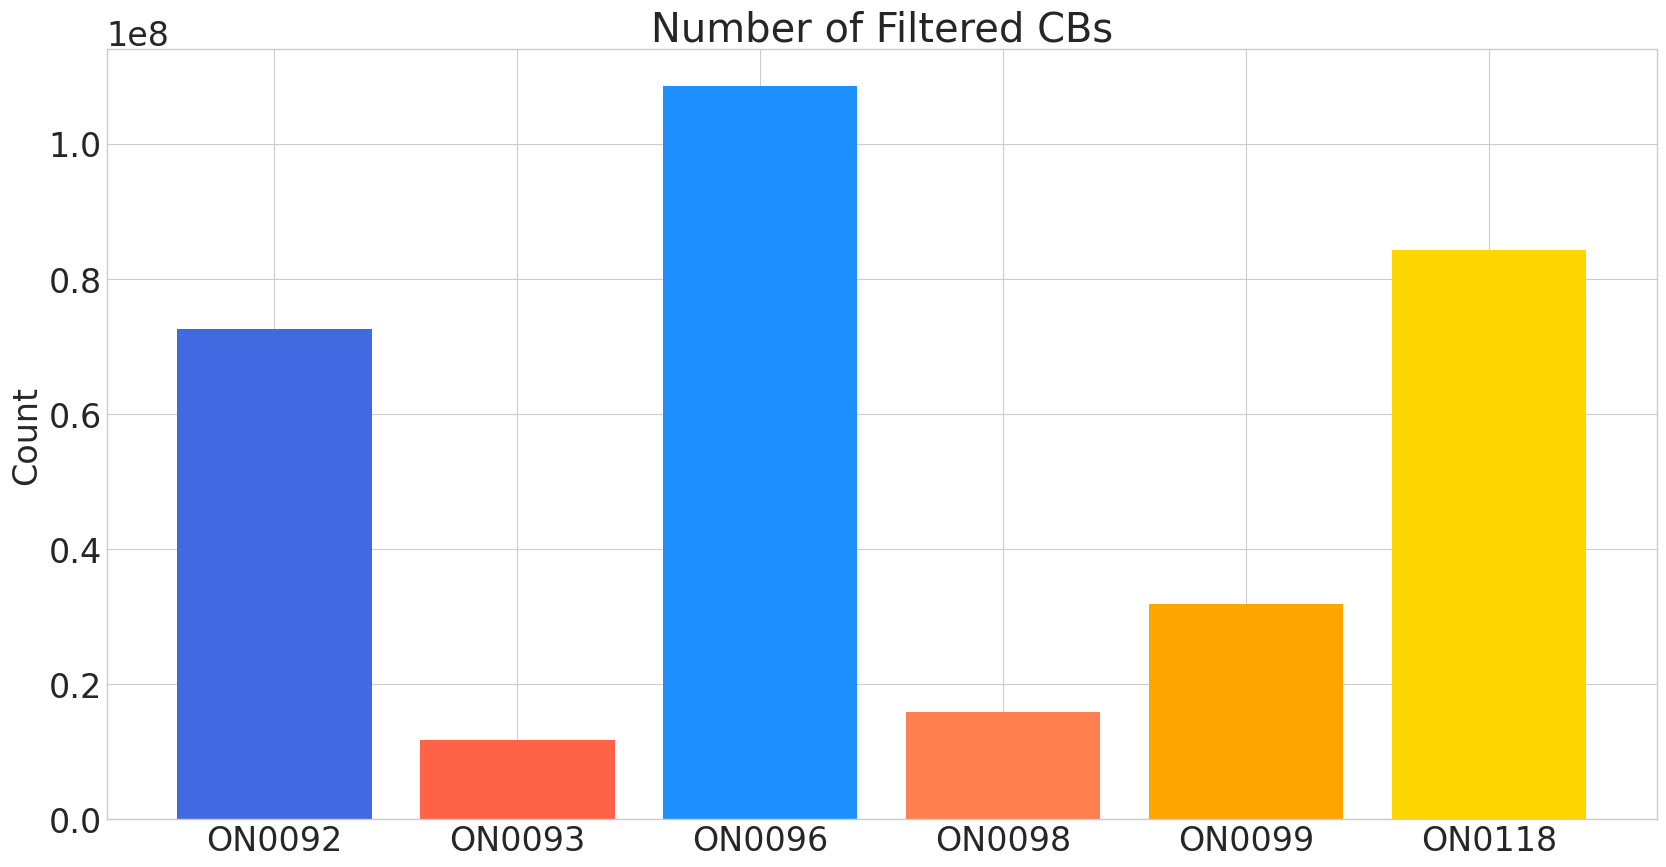

In [49]:
## Bar graph of count_dict

fig, ax = plt.subplots(1, 1, figsize=(20,10))
ax.bar(count_dict.keys(), count_dict.values(), color=[color_dict[k] for k in count_dict.keys()])
ax.set_title("Number of Filtered CBs")
ax.set_ylabel("Count")
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/plot/qc_251124/cb_count.png", dpi=300)
plt.show()

In [50]:
count_dict = {}
count_dict["ON0092"] = len(score_ON0092)
count_dict["ON0093"] = len(score_ON0093)
count_dict["ON0096"] = len(score_ON0096)
count_dict["ON0098"] = len(score_ON0098)
count_dict["ON0099"] = len(score_ON0099)
count_dict["ON0118"] = 161167105
print(count_dict)

{'ON0092': 128973869, 'ON0093': 57078606, 'ON0096': 177948232, 'ON0098': 70833009, 'ON0099': 77735408, 'ON0118': 161167105}


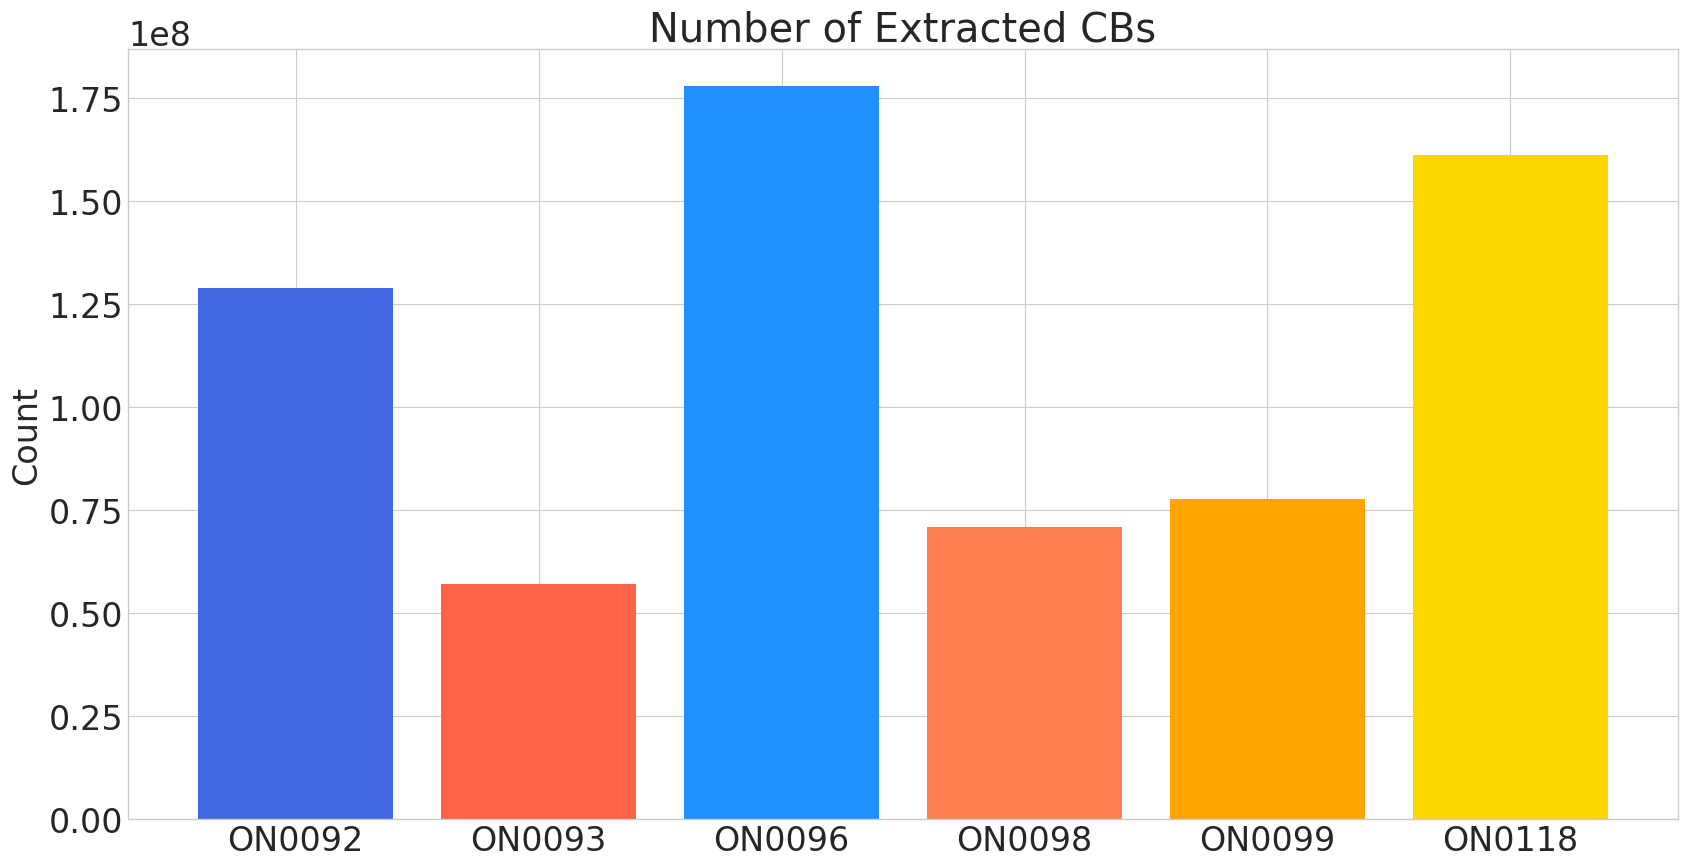

In [51]:
## Bar graph of count_dict

fig, ax = plt.subplots(1, 1, figsize=(20,10))
ax.bar(count_dict.keys(), count_dict.values(), color=[color_dict[k] for k in count_dict.keys()])
ax.set_title("Number of Extracted CBs")
ax.set_ylabel("Count")
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/plot/qc_251124/cb_count_prefilter.png", dpi=300)
plt.show()

In [1]:
count_dict = {}
count_dict["ON0092"] = len(score_ON0092)
count_dict["ON0093"] = len(score_ON0093)
count_dict["ON0096"] = len(score_ON0096)
count_dict["ON0098"] = len(score_ON0098)
count_dict["ON0099"] = len(score_ON0099)
count_dict["ON0118"] = 161167105
print(count_dict)

NameError: name 'score_ON0092' is not defined